# Inter-Rater Reliability: Methodological Rigour Scoring
Computes Cohen's kappa (unweighted and quadratic-weighted), percent agreement, mean absolute difference, and Spearman correlation between two independent reviewers' scores across the five methodological rigour criteria (Detection Performance, Theoretical Foundation, Computational Efficiency, Interpretability, Ecological Relevance) for the 15 studies in the systematic review. Averages both rater's scores scores across methodological paradigm.

In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr


DIMENSION_NAMES = [
    "Detection Performance",
    "Theoretical Foundation",
    "Computational Efficiency",
    "Interpretability",
    "Ecological Relevance"
]



# Rater 1 scores, per study, in the order above
# [Detection, Theoretical, Efficiency, Interpretability, Ecological Relevance]
studies_r1 = {
    'zaza2025': [2, 2, 1, 2, 3],
    'kareinen2025': [3, 2, 1, 1, 3],
    'SIDDAGANGAIAH': [2, 3, 3, 2, 3],
    'thecvfICCV': [2, 2, 2, 1, 3],
    'beyan': [2, 2, 2, 1, 3],
    '9607849': [2, 2, 2, 2, 3],
    'natureAnomBehav': [3, 2, 3, 2, 3],
    'otolith': [2, 2, 2, 2, 3],
    'Beyan2018': [1, 2, 2, 2, 3],
    'spatiotemporal': [1, 2, 1, 1, 3],
    'Bilik_2023': [2, 2, 2, 2, 3],
    'shutler': [2, 2, 3, 2, 3],
    'Wu': [3, 2, 2, 3, 3],
    'chuang': [2, 2, 2, 2, 3],
    'hammond': [1, 2, 2, 3, 3]
}


# Second rator's independent scores (final, post-calibration), same
# study keys and dimension order
studies_r2 = {
    'zaza2025': [2, 2, 2, 2, 3],
    'kareinen2025': [3, 2, 1, 1, 3],
    'SIDDAGANGAIAH': [2, 3, 2, 2, 3],
    'thecvfICCV': [2, 2, 2, 2, 3],
    'beyan': [2, 3, 2, 2, 3],
    '9607849': [2, 2, 2, 2, 3],
    'natureAnomBehav': [3, 2, 3, 2, 3],
    'otolith': [3, 2, 2, 2, 3],
    'Beyan2018': [2, 3, 2, 2, 3],
    'spatiotemporal': [1, 2, 1, 2, 3],
    'Bilik_2023': [3, 2, 2, 2, 3],
    'shutler': [2, 2, 2, 2, 3],
    'Wu': [2, 2, 2, 2, 3],
    'chuang': [2, 2, 2, 2, 3],
    'hammond': [2, 3, 2, 3, 3]
}

study_keys = list(studies_r1.keys())
r1_matrix = np.array([studies_r1[k] for k in study_keys])
r2_matrix = np.array([studies_r2[k] for k in study_keys])

print(f"Loaded {len(study_keys)} studies, {len(DIMENSION_NAMES)} dimensions each")
print(f"Total paired ratings: {len(study_keys) * len(DIMENSION_NAMES)}")

Loaded 15 studies, 5 dimensions each
Total paired ratings: 75


In [ ]:
def interpret_kappa(k):
    """Landis & Koch (1977) interpretation bands."""
    if k is None or np.isnan(k): return "Undefined (no variance)"
    if k < 0:      return "Poor"
    elif k < 0.21: return "Slight"
    elif k < 0.41: return "Fair"
    elif k < 0.61: return "Moderate"
    elif k < 0.81: return "Substantial"
    else:          return "Almost Perfect"


def safe_kappa(a, b, weights=None):
    """Cohen's kappa, returning NaN (without warnings) when it is undefined,
    i.e. when both raters give the same single score to every study."""
    if len(set(a)) == 1 and list(a) == list(b):
        return float('nan')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return cohen_kappa_score(a, b, weights=weights)


def compute_kappa(r1_matrix, r2_matrix, dimension_names):
    """
    Computes, per dimension and overall:
      - Unweighted Cohen's kappa (exact agreement only)
      - Weighted Cohen's kappa (quadratic weights, gives partial credit
        for near-misses e.g. a score of 2 vs 3)
      - Percent exact agreement
      - Mean absolute difference between raters
      - Spearman rank correlation

    Note: when a dimension has very low score variance (e.g. almost every
    study scores 3), kappa can appear low or undefined even when raw
    percent agreement is high. This is a known property of chance-corrected
    agreement statistics, and is reported alongside
    percent agreement so both can be interpreted together.
    """
    n_studies = len(r1_matrix)
    results = []
    all_r1 = []
    all_r2 = []

    print("  COHEN'S KAPPA INTER-RATER RELIABILITY ANALYSIS")
    print("  Methodological Rigour Scoring - Rater 1 vs Rater 2")
    print(f"  N = {n_studies} studies | {n_studies * len(dimension_names)} individual ratings")

    for dim_idx, dim_name in enumerate(dimension_names):
        n_dim = r1_matrix[:, dim_idx].tolist()
        r_dim = r2_matrix[:, dim_idx].tolist()

        all_r1.extend(n_dim)
        all_r2.extend(r_dim)

        kappa_unw = safe_kappa(n_dim, r_dim)
        kappa_w = safe_kappa(n_dim, r_dim, weights='quadratic')
        agreements = sum(1 for a, b in zip(n_dim, r_dim) if a == b)
        pct_agree = (agreements / len(n_dim)) * 100
        mad = np.mean([abs(a - b) for a, b in zip(n_dim, r_dim)])

        # Spearman correlation is undefined when one rater's scores are
        # constant across all studies (zero variance); guard against that
        if len(set(n_dim)) == 1 or len(set(r_dim)) == 1:
            rho, pval = float('nan'), float('nan')
        else:
            rho, pval = spearmanr(n_dim, r_dim)

        results.append({
            'Dimension': dim_name,
            'Kappa (weighted)': round(kappa_w, 3),
            'Kappa (unweighted)': round(kappa_unw, 3),
            'Agreement (%)': round(pct_agree, 1),
            'Mean Abs. Diff': round(mad, 2),
            'Spearman r': round(rho, 3) if not np.isnan(rho) else 'undefined',
            'p-value': round(pval, 3) if not np.isnan(pval) else 'undefined',
            'Interpretation': interpret_kappa(kappa_w)
        })

        print(f"\n  {dim_name}:")
        print(f"    Weighted Kappa:    {kappa_w:.3f}  ({interpret_kappa(kappa_w)})")
        print(f"    Unweighted Kappa:  {kappa_unw:.3f}  ({interpret_kappa(kappa_unw)})")
        print(f"    Agreement:         {pct_agree:.1f}%")
        print(f"    Mean Abs. Diff:    {mad:.2f}")
        if np.isnan(rho):
            print(f"    Spearman r:        undefined (one rater's scores are constant)")
        else:
            print(f"    Spearman r:        {rho:.3f}  (p = {pval:.3f})")

    # Overall, all dimensions pooled together
    print("\n" + "=" * 72)
    print(f"  OVERALL (all {len(dimension_names)} dimensions combined)")
    print("=" * 72)

    kappa_all_w = safe_kappa(all_r1, all_r2, weights='quadratic')
    kappa_all_u = safe_kappa(all_r1, all_r2)
    overall_agree = sum(1 for a, b in zip(all_r1, all_r2) if a == b)
    overall_pct = (overall_agree / len(all_r1)) * 100
    overall_mad = np.mean([abs(a - b) for a, b in zip(all_r1, all_r2)])
    rho_all, pval_all = spearmanr(all_r1, all_r2)

    print(f"    Weighted Kappa:    {kappa_all_w:.3f}  ({interpret_kappa(kappa_all_w)})")
    print(f"    Unweighted Kappa:  {kappa_all_u:.3f}  ({interpret_kappa(kappa_all_u)})")
    print(f"    Agreement:         {overall_pct:.1f}%")
    print(f"    Mean Abs. Diff:    {overall_mad:.2f}")
    print(f"    Spearman r:        {rho_all:.3f}  (p = {pval_all:.4f})")

    overall = {
        'n_studies': n_studies,
        'n_ratings': len(all_r1),
        'weighted_kappa': kappa_all_w,
        'unweighted_kappa': kappa_all_u,
        'percent_agreement': overall_pct,
        'mean_abs_diff': overall_mad,
        'spearman_r': rho_all,
        'interpretation': interpret_kappa(kappa_all_w)
    }

    return pd.DataFrame(results), overall, all_r1, all_r2

In [ ]:
df_results, overall, all_r1, all_r2 = compute_kappa(
    r1_matrix, r2_matrix, DIMENSION_NAMES
)

print("\n" + "=" * 72)
print("  SUMMARY TABLE")
print("=" * 72)
print(df_results.to_string(index=False))


  COHEN'S KAPPA INTER-RATER RELIABILITY ANALYSIS
  Methodological Rigour Scoring - Rater 1 vs Rater 2
  N = 15 studies | 75 individual ratings

  Detection Performance:
    Weighted Kappa:    0.545  (Moderate)
    Unweighted Kappa:  0.375  (Fair)
    Agreement:         66.7%
    Mean Abs. Diff:    0.33
    Spearman r:        0.574  (p = 0.025)

  Theoretical Foundation:
    Weighted Kappa:    0.328  (Fair)
    Unweighted Kappa:  0.328  (Fair)
    Agreement:         80.0%
    Mean Abs. Diff:    0.20
    Spearman r:        0.443  (p = 0.098)

  Computational Efficiency:
    Weighted Kappa:    0.667  (Substantial)
    Unweighted Kappa:  0.583  (Moderate)
    Agreement:         80.0%
    Mean Abs. Diff:    0.20
    Spearman r:        0.716  (p = 0.003)

  Interpretability:
    Weighted Kappa:    0.500  (Moderate)
    Unweighted Kappa:  0.412  (Moderate)
    Agreement:         73.3%
    Mean Abs. Diff:    0.27
    Spearman r:        0.579  (p = 0.024)

  Ecological Relevance:
    Weighted K

# Plots
Figure 1 shows weighted vs unweighted kappa per dimension against the Landis & Koch (1977) interpretation bands. Figure 2 shows the full score concordance matrix (all 75 ratings pooled).

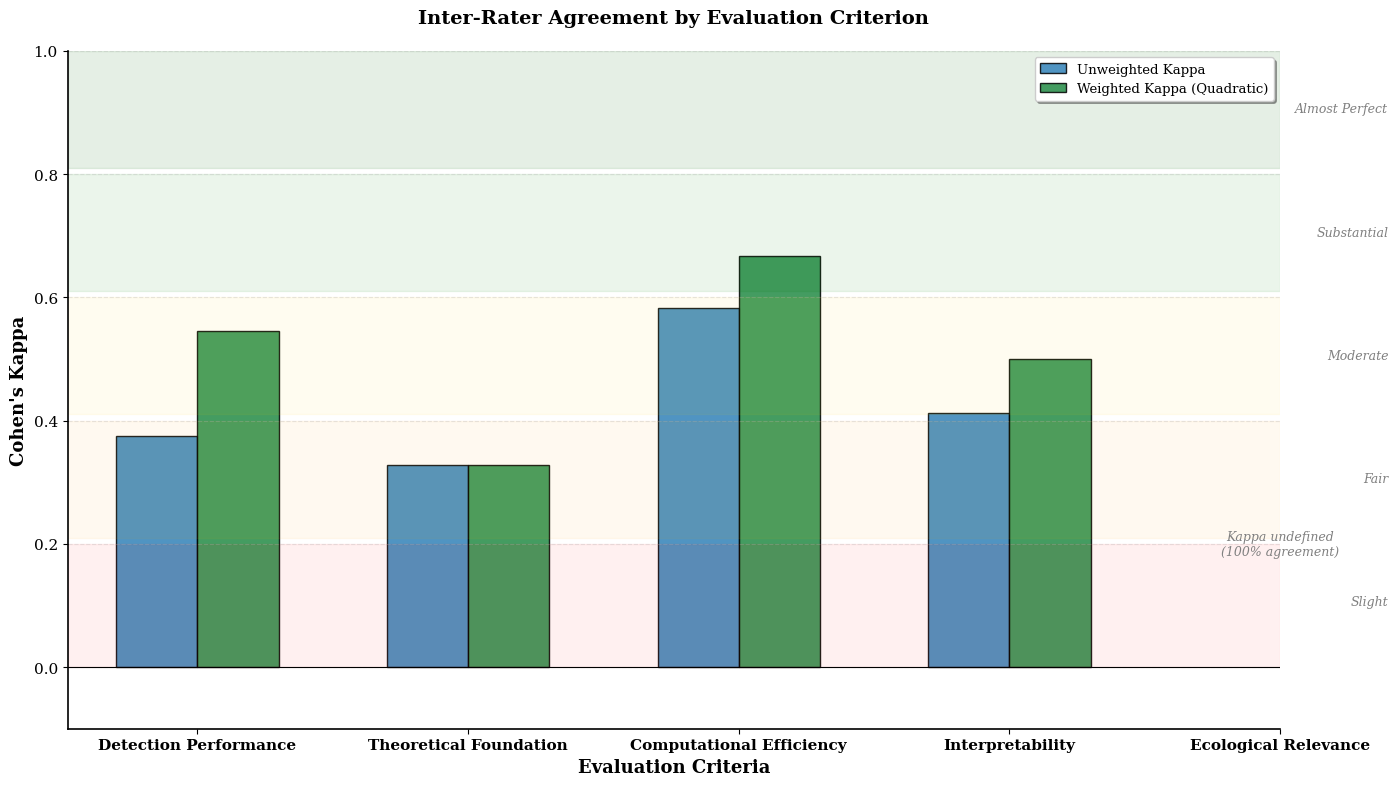

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'


PASTEL_BLUES = ['#B8D4E8', '#8BB8D8', '#5E9DC8', '#3182B8', '#1C6BA0']
PASTEL_GREENS = ['#C7E9C0', '#A1D99B', '#74C476', '#41AB5D', '#238B45']
PASTEL_ORANGE = '#FFD1A3'

# --- FIGURE 1: Inter-Rater Agreement by Dimension (bar chart) ---
fig1, ax1 = plt.subplots(figsize=(14, 8))

dims_full = DIMENSION_NAMES
kappa_unw = df_results['Kappa (unweighted)'].values
kappa_w   = df_results['Kappa (weighted)'].values

x = np.arange(len(dims_full))
width = 0.3

bars1 = ax1.bar(x - width/2, kappa_unw, width, label='Unweighted Kappa',
                color=PASTEL_BLUES[3], edgecolor='black', linewidth=1, alpha=0.85)
bars2 = ax1.bar(x + width/2, kappa_w, width, label='Weighted Kappa (Quadratic)',
                color=PASTEL_GREENS[4], edgecolor='black', linewidth=1, alpha=0.85)

# Mark criteria where kappa is undefined (both raters gave every study the same score)
for i, (ku, kw) in enumerate(zip(kappa_unw, kappa_w)):
    if np.isnan(ku) and np.isnan(kw):
        ax1.text(i, 0.20, 'Kappa undefined\n(100% agreement)',
                 ha='center', va='center', fontsize=9, color='gray', style='italic')

# Landis & Koch (1977) interpretation zones
ax1.axhspan(0.00, 0.20, alpha=0.06, color='red')
ax1.axhspan(0.21, 0.40, alpha=0.06, color='orange')
ax1.axhspan(0.41, 0.60, alpha=0.06, color='gold')
ax1.axhspan(0.61, 0.80, alpha=0.08, color='green')
ax1.axhspan(0.81, 1.00, alpha=0.10, color='darkgreen')

ax1.text(len(dims_full) - 0.6, 0.10, 'Slight', fontsize=9, ha='right', color='gray', style='italic')
ax1.text(len(dims_full) - 0.6, 0.30, 'Fair', fontsize=9, ha='right', color='gray', style='italic')
ax1.text(len(dims_full) - 0.6, 0.50, 'Moderate', fontsize=9, ha='right', color='gray', style='italic')
ax1.text(len(dims_full) - 0.6, 0.70, 'Substantial', fontsize=9, ha='right', color='gray', style='italic')
ax1.text(len(dims_full) - 0.6, 0.90, 'Almost Perfect', fontsize=9, ha='right', color='gray', style='italic')

ax1.set_ylabel("Cohen's Kappa", fontsize=13, fontweight='bold')
ax1.set_xlabel('Evaluation Criteria', fontsize=13, fontweight='bold')
ax1.set_title('Inter-Rater Agreement by Evaluation Criterion',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(dims_full, fontsize=11, fontweight='bold')
ax1.set_ylim(-0.1, 1)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9.5)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cohens_kappa_by_dimension.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()
files.download('cohens_kappa_by_dimension.png')

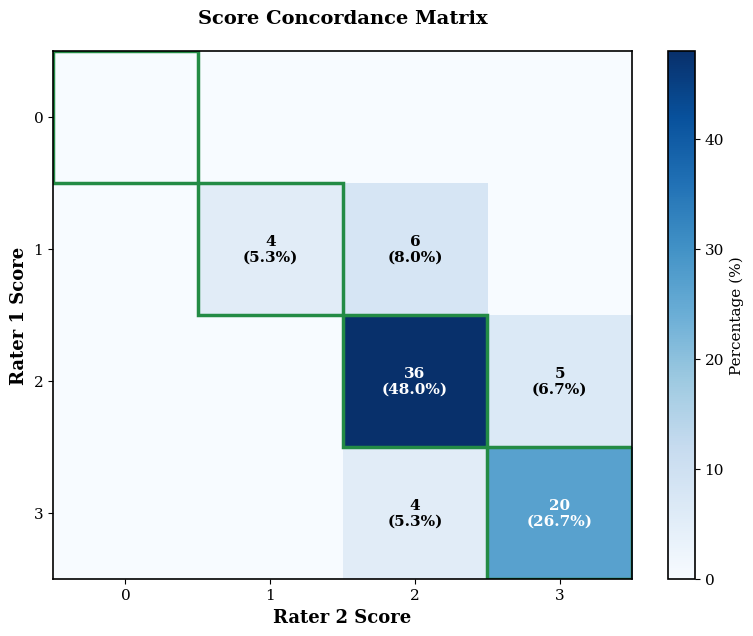

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- FIGURE 2: Score Concordance Matrix (heatmap) ---
fig2, ax2 = plt.subplots(figsize=(8, 6.5))

agree_matrix = np.zeros((4, 4))
for r1, r2 in zip(all_r1, all_r2):
    agree_matrix[r1, r2] += 1
agree_pct = agree_matrix / agree_matrix.sum() * 100

im = ax2.imshow(agree_pct, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1, 2, 3])
ax2.set_yticks([0, 1, 2, 3])
ax2.set_xticklabels(['0', '1', '2', '3'], fontsize=11)
ax2.set_yticklabels(['0', '1', '2', '3'], fontsize=11)
ax2.set_xlabel("Rater 2 Score", fontsize=13, fontweight='bold')
ax2.set_ylabel("Rater 1 Score", fontsize=13, fontweight='bold')
ax2.set_title("Score Concordance Matrix",
              fontsize=14, fontweight='bold', pad=20)

for i in range(4):
    for j in range(4):
        count = int(agree_matrix[i, j])
        pct = agree_pct[i, j]
        if count > 0:
            color = 'white' if pct > 15 else 'black'
            ax2.text(j, i, f'{count}\n({pct:.1f}%)', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

# Highlight diagonal (agreement cells)
for i in range(4):
    ax2.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False,
                                edgecolor=PASTEL_GREENS[4], linewidth=2.5))

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Percentage (%)', fontsize=11)

plt.tight_layout()
plt.savefig('cohens_kappa_concordance_matrix.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()
files.download('cohens_kappa_concordance_matrix.png')

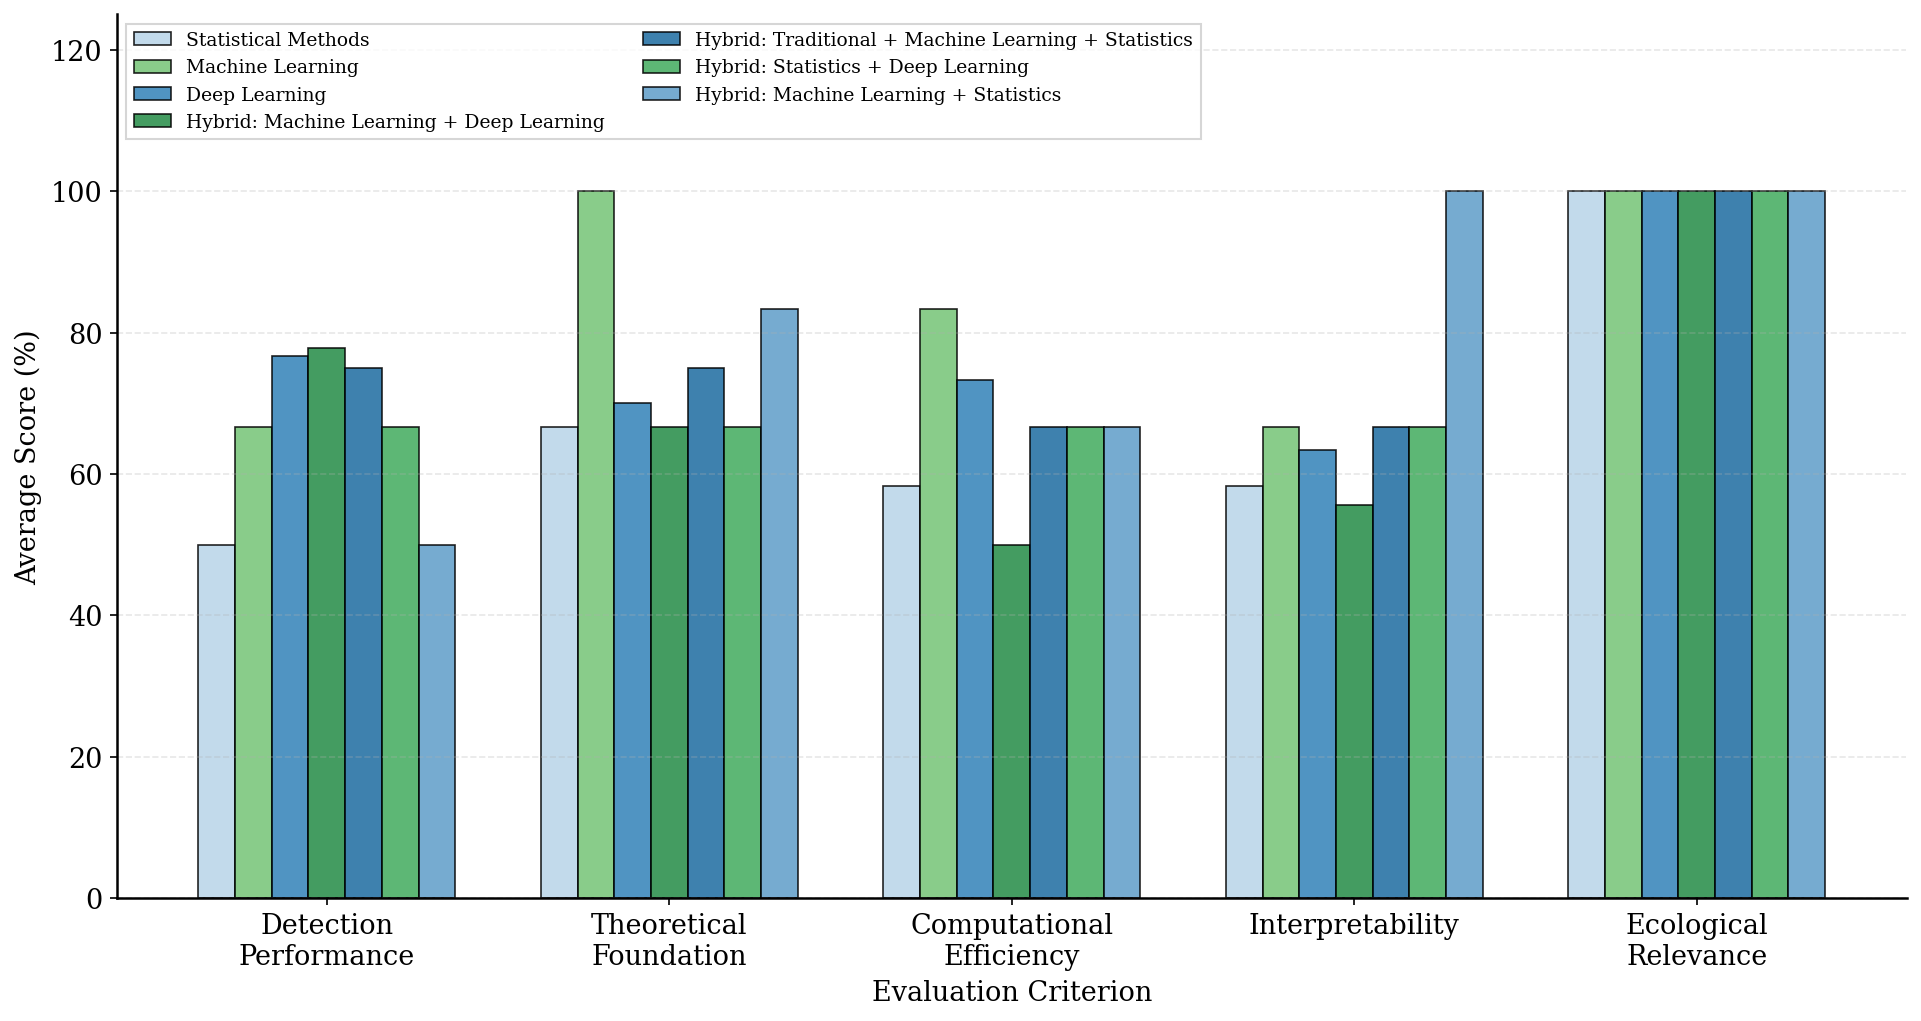

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

STYLE = {
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          13,
    'axes.linewidth':     1.2,
    'axes.titlesize':     13,
    'axes.titleweight':   'normal',
    'axes.labelsize':     13,
    'axes.labelweight':   'normal',
    'xtick.labelsize':    13,
    'ytick.labelsize':    13,
    'legend.fontsize':    13,
    'legend.title_fontsize': 13,
    'legend.frameon':     True,
    'legend.edgecolor':   '0.8',
    'legend.fancybox':    False,
    'legend.shadow':      False,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'figure.dpi':         150,
    'savefig.dpi':        600,
    'savefig.bbox':       'tight',
    'savefig.transparent': True,
}

BLUES  = ['#B8D4E8', '#8BB8D8', '#5E9DC8', '#3182B8', '#1C6BA0']
GREENS = ['#C7E9C0', '#A1D99B', '#74C476', '#41AB5D', '#238B45']

study_categories = {
    'zaza2025':       'Hybrid: Machine Learning + Deep Learning',
    'kareinen2025':   'Hybrid: Machine Learning + Deep Learning',
    'SIDDAGANGAIAH':  'Machine Learning',
    'thecvfICCV':     'Deep Learning',
    'beyan':          'Hybrid: Traditional Methods + Machine Learning + Statistical Methods',
    '9607849':        'Hybrid: Machine Learning + Deep Learning',
    'natureAnomBehav':'Deep Learning',
    'otolith':        'Deep Learning',
    'Beyan2018':      'Deep Learning',
    'spatiotemporal': 'Statistical Methods',
    'Bilik_2023':     'Deep Learning',
    'shutler':        'Statistical Methods',
    'Wu':             'Hybrid: Traditional Methods + Machine Learning + Statistical Methods',
    'chuang':         'Hybrid: Statistical Methods + Deep Learning',
    'hammond':        'Hybrid: Machine Learning + Statistical Methods',
}

CAT_ORDER = [
    'Statistical Methods',
    'Machine Learning',
    'Deep Learning',
    'Hybrid: Machine Learning + Deep Learning',
    'Hybrid: Traditional Methods + Machine Learning + Statistical Methods',
    'Hybrid: Statistical Methods + Deep Learning',
    'Hybrid: Machine Learning + Statistical Methods',
]
CAT_COLORS_15 = dict(zip(CAT_ORDER, [BLUES[0], GREENS[2], BLUES[3], GREENS[4],
                                     BLUES[4], GREENS[3], BLUES[2]]))
CAT_LABELS = [
    'Statistical\nMethods',
    'Machine\nLearning',
    'Deep\nLearning',
    'Hybrid:\nMachine Learning +\nDeep Learning',
    'Hybrid:\nTraditional + Machine\nLearning + Statistics',
    'Hybrid:\nStatistics +\nDeep Learning',
    'Hybrid:\nMachine Learning +\nStatistics',
]
metric_labels = ['Detection\nPerformance', 'Theoretical\nFoundation',
                 'Computational\nEfficiency', 'Interpretability', 'Ecological\nRelevance']

assert set(studies_r1) == set(studies_r2) == set(study_categories), \
    "Study keys differ between Rater 1, Rater 2 and the category map"

# average of the two raters for each study, then mean per category as % of maximum (3)
avg_scores = {k: (np.array(studies_r1[k]) + np.array(studies_r2[k])) / 2.0
              for k in studies_r1}

def cat_avg(study_list):
    arr = np.array([avg_scores[s] for s in study_list])
    return (arr.mean(axis=0) / 3.0 * 100).tolist()

cat_study_map = {c: [s for s, cat in study_categories.items() if cat == c] for c in CAT_ORDER}
avgs = {c: cat_avg(cat_study_map[c]) for c in CAT_ORDER}
data = np.array([avgs[c] for c in CAT_ORDER])

x     = np.arange(len(metric_labels))
n_cat = len(CAT_ORDER)
width = 0.75 / n_cat

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(13, 7))

    for i, (cat, short) in enumerate(zip(CAT_ORDER, CAT_LABELS)):
        offset = (i - (n_cat - 1) / 2) * width
        ax.bar(x + offset, data[i], width, label=short.replace('\n', ' '),
               color=CAT_COLORS_15[cat], edgecolor='black', linewidth=0.8, alpha=0.85)

    ax.set_ylabel('Average Score (%)')
    ax.set_xlabel('Evaluation Criterion')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 125)
    ax.legend(loc='upper left', ncol=2, fontsize=9)
    ax.grid(axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('average_evaluation_scores.png')
    plt.show()

files.download('average_evaluation_scores.png')